In [5]:

print("Downloading raw data from Kaggle...")
path = kagglehub.dataset_download("wyattowalsh/basketball")
csv_folder = path
for root, dirs, files in os.walk(path):
    if "play_by_play.csv" in files:
        csv_folder = root
        break


spark = SparkSession.builder.appName("NBA_Setup").getOrCreate()


df_pbp_raw = spark.read.csv(os.path.join(csv_folder, "play_by_play.csv"), header=True, inferSchema=True)
df_game_raw = spark.read.csv(os.path.join(csv_folder, "game.csv"), header=True, inferSchema=True)
df_player_raw = spark.read.csv(os.path.join(csv_folder, "common_player_info.csv"), header=True, inferSchema=True)

def clean_game_data(df):
    return df.select(
        F.col("game_id").cast(StringType()),
        F.col("season_id").cast(StringType()),
        F.col("game_date"),
        F.col("team_id_home"),
        F.col("team_id_away")
    ).distinct()

def clean_pbp_data(df):
    df = df.withColumn("scoreMargin_clean", 
        F.when(F.col("scoreMargin") == "TIE", 0)
         .otherwise(F.col("scoreMargin"))
    ).withColumn("scoreMargin_clean", F.col("scoreMargin_clean").cast(IntegerType()))
    
    return df.select(
        F.col("game_id").cast(StringType()),
        F.col("eventnum").cast(IntegerType()),
        F.col("eventmsgtype").cast(IntegerType()), 
        F.col("eventmsgactiontype").cast(IntegerType()),
        F.col("period").cast(IntegerType()),
        F.col("pctimestring").alias("time_remaining"),
        F.col("scoreMargin_clean").alias("score_margin"),
        F.col("person1type"),
        F.col("player1_id"), 
        F.col("player2_id"),
        F.col("player3_id"),
        F.col("homedescription"),
        F.col("visitordescription")
    ).na.fill(0, subset=["score_margin"])

def clean_player_data(df):
    return df.select(
        F.col("person_id").cast(IntegerType()),
        F.col("display_first_last").alias("player_name_full")
    ).distinct()

df_game = clean_game_data(df_game_raw)
df_pbp = clean_pbp_data(df_pbp_raw)
df_player = clean_player_data(df_player_raw)

df_pbp_season = df_pbp.join(df_game, on="game_id", how="inner")

df_pbp_final = df_pbp_season.join(
    df_player, 
    df_pbp_season.player1_id == df_player.person_id, 
    how="left"
).drop("person_id")

OUTPUT_PBP = "processed_data/nba_pbp_cleaned.parquet"
df_pbp_final.write.mode("overwrite").parquet(OUTPUT_PBP)

def contains(col, text):
    return F.instr(F.lower(col), text.lower()) > 0

df_events = df_pbp_final \
    .withColumn("is_miss", (contains("homedescription", "MISS") | contains("visitordescription", "MISS"))) \
    .withColumn("is_three", (contains("homedescription", "3PT") | contains("visitordescription", "3PT"))) \
    .withColumn("fg_make", (F.col("eventmsgtype") == 1).cast("int")) \
    .withColumn("fg_miss", (F.col("eventmsgtype") == 2).cast("int")) \
    .withColumn("ft_make", ((F.col("eventmsgtype") == 3) & (~F.col("is_miss"))).cast("int")) \
    .withColumn("ft_miss", ((F.col("eventmsgtype") == 3) & (F.col("is_miss"))).cast("int")) \
    .withColumn("points", 
        F.when(F.col("fg_make") == 1, F.when(F.col("is_three"), 3).otherwise(2))
         .when(F.col("ft_make") == 1, 1)
         .otherwise(0)
    ) \
    .withColumn("rebound", (contains("homedescription", "rebound") | contains("visitordescription", "rebound")).cast("int")) \
    .withColumn("assist", (contains("homedescription", " ast") | contains("visitordescription", " ast")).cast("int")) \
    .withColumn("steal", (contains("homedescription", "steal") | contains("visitordescription", "steal")).cast("int")) \
    .withColumn("block", (contains("homedescription", "block") | contains("visitordescription", "block")).cast("int")) \
    .withColumn("turnover", (F.col("eventmsgtype") == 5).cast("int")) \
    .withColumn("foul", (F.col("eventmsgtype") == 6).cast("int"))

OUTPUT_EVENTS = "processed_data/events_clean.parquet"
df_events.write.mode("overwrite").parquet(OUTPUT_EVENTS)


100%|██████████| 697M/697M [00:06<00:00, 111MB/s]  

Extracting files...


Raw CSVs found in: /storage/home/vxk5175/.cache/kagglehub/datasets/wyattowalsh/basketball/versions/231/csv


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/07 20:54:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Loading raw CSVs...


Processing PBP data...


✅ Saved processed_data/nba_pbp_cleaned.parquet
Parsing events (Shots/Rebounds/etc)...


25/12/07 20:55:48 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


✅ Saved processed_data/events_clean.parquet
Setup Complete! You can now run the Clutch Engineering script.


In [4]:
import kagglehub
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, StringType

In [3]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 68 kB 1.5 MB/s eta 0:00:011


In [6]:
spark = SparkSession.builder.appName("NBA_Clutch_Engineering").getOrCreate()

PBP_PATH = "processed_data/nba_pbp_cleaned.parquet"
EVENTS_PATH = "processed_data/events_clean.parquet"
OUTPUT_PATH = "processed_data/clutch_events.parquet"

df_pbp = spark.read.parquet(PBP_PATH)
df_events = spark.read.parquet(EVENTS_PATH)

df_pbp_time = df_pbp.withColumn(
    "clock_str", 
    F.substring(F.col("time_remaining").cast("string"), 12, 5) 
).withColumn(
    "seconds_left",
    (F.split(F.col("clock_str"), ":")[0].cast("int") * 60) + 
    F.split(F.col("clock_str"), ":")[1].cast("int")
)

print("Applying Clutch Filters (4th Qtr, +/- 5 pts, < 5 mins)...")
df_clutch_pbp = df_pbp_time.filter(
    (F.col("period") == 4) &
    (F.abs(F.col("score_margin")) <= 5) &
    (F.col("seconds_left") <= 300) 
)


df_final = df_clutch_pbp.alias("pbp").join(
    df_events.alias("stats"),
    (F.col("pbp.game_id") == F.col("stats.game_id")) &
    (F.col("pbp.eventnum") == F.col("stats.eventnum")),
    "inner"
).select(
    F.col("pbp.game_id"),
    F.col("pbp.season_id"),
    F.col("pbp.eventnum"),
    F.col("pbp.seconds_left"),
    F.col("pbp.score_margin"),
    F.col("stats.player1_id").alias("player_id"),
    F.col("stats.player_name_full").alias("player_name"),
    F.col("stats.points"),
    F.col("stats.fg_make"),
    F.col("stats.fg_miss"),
    F.col("stats.ft_make"),
    F.col("stats.ft_miss"),
    F.col("stats.rebound"),
    F.col("stats.assist"),
    F.col("stats.steal"),
    F.col("stats.turnover")
)


df_final.write.mode("overwrite").parquet(OUTPUT_PATH)


25/12/07 20:56:57 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


Loading clean data...
Applying Clutch Filters (4th Qtr, +/- 5 pts, < 5 mins)...


Saving 1352230 clutch events...


SUCCESS: Clutch events saved to processed_data/clutch_events.parquet


In [7]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F


spark = SparkSession.builder.appName("NBA_Player_Clutch_Stats").getOrCreate()


CLUTCH_EVENTS_PATH = "processed_data/clutch_events.parquet"
OUTPUT_PATH = "processed_data/player_clutch_stats.parquet"


df_clutch = spark.read.parquet(CLUTCH_EVENTS_PATH)

df_clutch = df_clutch.filter(F.col("player_id").isNotNull())

df_agg = (
    df_clutch
    .groupBy("player_id", "player_name")
    .agg(
        F.sum("points").alias("clutch_points"),
        F.sum("fg_make").alias("clutch_fg_make"),
        F.sum("fg_miss").alias("clutch_fg_miss"),
        F.sum("ft_make").alias("clutch_ft_make"),
        F.sum("ft_miss").alias("clutch_ft_miss"),
        F.sum("assist").alias("clutch_assists"),
        F.sum("rebound").alias("clutch_rebounds"),
        F.sum("steal").alias("clutch_steals"),
        F.sum("turnover").alias("clutch_turnovers"),
        F.countDistinct("game_id").alias("clutch_games_played")
    )
)

df_stats = (
    df_agg
    .withColumn(
        "clutch_fg_attempts",
        F.col("clutch_fg_make") + F.col("clutch_fg_miss")
    )
    .withColumn(
        "clutch_ft_attempts",
        F.col("clutch_ft_make") + F.col("clutch_ft_miss")
    )
    .withColumn(
        "clutch_fg_pct",
        F.when(F.col("clutch_fg_attempts") > 0,
               F.col("clutch_fg_make") / F.col("clutch_fg_attempts"))
         .otherwise(F.lit(None).cast("double"))
    )
    .withColumn(
        "clutch_ft_pct",
        F.when(F.col("clutch_ft_attempts") > 0,
               F.col("clutch_ft_make") / F.col("clutch_ft_attempts"))
         .otherwise(F.lit(None).cast("double"))
    )
    .withColumn(
        "clutch_possessions_used",
        F.col("clutch_fg_attempts") +
        F.col("clutch_ft_attempts") +
        F.col("clutch_turnovers")
    )
)

df_stats.orderBy(F.desc("clutch_points")).show(20, truncate=False)

(
    df_stats
    .select(
        "player_id",
        "player_name",
        "clutch_games_played",
        "clutch_possessions_used",
        "clutch_points",
        "clutch_fg_make", "clutch_fg_miss", "clutch_fg_attempts", "clutch_fg_pct",
        "clutch_ft_make", "clutch_ft_miss", "clutch_ft_attempts", "clutch_ft_pct",
        "clutch_assists", "clutch_rebounds", "clutch_steals", "clutch_turnovers"
    )
    .write
    .mode("overwrite")
    .parquet(OUTPUT_PATH)
)



25/12/07 20:57:54 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


+---------+---------------+-------------+--------------+--------------+--------------+--------------+--------------+---------------+-------------+----------------+-------------------+------------------+------------------+-------------------+-------------+-----------------------+
|player_id|player_name    |clutch_points|clutch_fg_make|clutch_fg_miss|clutch_ft_make|clutch_ft_miss|clutch_assists|clutch_rebounds|clutch_steals|clutch_turnovers|clutch_games_played|clutch_fg_attempts|clutch_ft_attempts|clutch_fg_pct      |clutch_ft_pct|clutch_possessions_used|
+---------+---------------+-------------+--------------+--------------+--------------+--------------+--------------+---------------+-------------+----------------+-------------------+------------------+------------------+-------------------+-------------+-----------------------+
|2544     |LeBron James   |1509         |675           |1791          |0             |491           |174           |1301           |276          |491           

Saved player-level clutch stats to processed_data/player_clutch_stats.parquet


In [13]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder.appName("NBA_Clutch_Rankings_and_Bias").getOrCreate()

INPUT_PATH = "processed_data/player_clutch_stats.parquet"
RANKINGS_PATH = "processed_data/clutch_player_rankings.parquet"

print("Loading player-level clutch stats...")
df_stats_raw = spark.read.parquet(INPUT_PATH)

# Drop rows with missing player names (data limitation)
df_stats = df_stats_raw.filter(F.col("player_name").isNotNull())

# Core derived metrics used everywhere
df_stats = (
    df_stats
    .withColumn(
        "clutch_possessions_used",
        F.col("clutch_fg_make") + F.col("clutch_fg_miss") +
        F.col("clutch_ft_make") + F.col("clutch_ft_miss") +
        F.col("clutch_turnovers")
    )
    .withColumn(
        "points_per_poss",
        F.when(F.col("clutch_possessions_used") > 0,
               F.col("clutch_points") / F.col("clutch_possessions_used"))
         .otherwise(F.lit(None).cast("double"))
    )
    .withColumn(
        "usage_per_game",
        F.when(F.col("clutch_games_played") > 0,
               F.col("clutch_possessions_used") / F.col("clutch_games_played"))
         .otherwise(F.lit(None).cast("double"))
    )
)

# Save the enriched full table for future analysis
df_stats.write.mode("overwrite").parquet(RANKINGS_PATH)
print(f"Saved full rankings table to {RANKINGS_PATH}")





#Top 20 Clutch Scorers of All Time (by total clutch points)

top20_scorers = (
    df_stats
    .orderBy(F.desc("clutch_points"))
    .limit(20)
    .select(
        "player_id",
        "player_name",
        "clutch_points",
        "clutch_games_played",
        "clutch_possessions_used",
        "points_per_poss"
    )
)

print("\nTop 20 Clutch Scorers (by total clutch points):")
top20_scorers.show(truncate=False)

top20_scorers.write.mode("overwrite").parquet("processed_data/top20_clutch_scorers.parquet")



#Top 20 Clutch FG% (Minimum Attempts Threshold)

MIN_FGA_FOR_FG_LEADER = 50 

top20_fg_pct = (
    df_stats
    .filter(F.col("clutch_fg_attempts") >= MIN_FGA_FOR_FG_LEADER)
    .orderBy(F.desc("clutch_fg_pct"))
    .limit(20)
    .select(
        "player_id",
        "player_name",
        "clutch_fg_attempts",
        "clutch_fg_make",
        "clutch_fg_miss",
        "clutch_fg_pct",
        "clutch_points",
        "points_per_poss"
    )
)

print("\nTop 20 Clutch FG% (min 50 FGA):")
top20_fg_pct.show(truncate=False)

top20_fg_pct.write.mode("overwrite").parquet("processed_data/top20_clutch_fg_pct.parquet")



#High Usage, Low Efficiency Players (Overrated Clutch)

HIGH_USAGE_MIN = 3.0      # possessions per game
MIN_POSS_HIGH = 50        # total clutch possessions
MIN_FGA_HIGH = 30         # at least 30 clutch FGA
MAX_PPP_OVER = 0.9        # low efficiency cutoff (points per possession)

high_usage_low_eff = (
    df_stats
    .filter(F.col("clutch_games_played") >= 20)
    .filter(F.col("clutch_possessions_used") >= MIN_POSS_HIGH)
    .filter(F.col("clutch_fg_attempts") >= MIN_FGA_HIGH)
    .filter(F.col("usage_per_game") >= HIGH_USAGE_MIN)
    .filter(F.col("points_per_poss") <= MAX_PPP_OVER)
    .orderBy(F.desc("usage_per_game"), F.asc("points_per_poss"))
    .limit(20)
    .select(
        "player_id",
        "player_name",
        "clutch_games_played",
        "clutch_possessions_used",
        "usage_per_game",
        "clutch_points",
        "points_per_poss",
        "clutch_fg_attempts",
        "clutch_fg_pct"
    )
)

print("\nHigh Usage, Low Efficiency Players (Overrated Clutch):")
high_usage_low_eff.show(truncate=False)

high_usage_low_eff.write.mode("overwrite").parquet("processed_data/high_usage_low_eff.parquet")



# Low Usage, High Efficiency Players (Underrated Clutch)

LOW_USAGE_MAX = 2.0       # possessions per game
MIN_POSS_LOW = 20         # total clutch possessions
MIN_FGA_LOW = 10          # at least 10 FGA
MIN_PPP_UNDER = 1.1       # high efficiency cutoff

low_usage_high_eff = (
    df_stats
    .filter(F.col("clutch_games_played") >= 20)
    .filter(F.col("clutch_possessions_used") >= MIN_POSS_LOW)
    .filter(F.col("clutch_fg_attempts") >= MIN_FGA_LOW)
    .filter(F.col("usage_per_game") <= LOW_USAGE_MAX)
    .filter(F.col("points_per_poss") >= MIN_PPP_UNDER)
    .orderBy(F.desc("points_per_poss"))
    .limit(20)
    .select(
        "player_id",
        "player_name",
        "clutch_games_played",
        "clutch_possessions_used",
        "usage_per_game",
        "clutch_points",
        "points_per_poss",
        "clutch_fg_attempts",
        "clutch_fg_pct"
    )
)

print("\nLow Usage, High Efficiency Players (Underrated Clutch):")
low_usage_high_eff.show(truncate=False)

low_usage_high_eff.write.mode("overwrite").parquet("processed_data/low_usage_high_eff.parquet")



#ERA BIAS ANALYSIS (90s vs 2000s vs 2010s vs 2020s)

print("\n=== ERA BIAS ANALYSIS (90s vs 2000s vs 2010s vs 2020s) ===")

CLUTCH_EVENTS_PATH = "processed_data/clutch_events.parquet"

# Load event-level clutch data
df_clutch_events = spark.read.parquet(CLUTCH_EVENTS_PATH)

# Extract a reasonable starting year from season_id.
# NBA stats convention: season_id like 22014 -> 2014-15 season,
# so `season_id % 10000` gives 2014.
df_clutch_era = (
    df_clutch_events
    .withColumn("season_int", F.col("season_id").cast("int"))
    .withColumn("season_start_year", (F.col("season_int") % F.lit(10000)))
    .withColumn(
        "era",
        F.when((F.col("season_start_year") >= 1990) & (F.col("season_start_year") <= 1999), "1990s")
         .when((F.col("season_start_year") >= 2000) & (F.col("season_start_year") <= 2009), "2000s")
         .when((F.col("season_start_year") >= 2010) & (F.col("season_start_year") <= 2019), "2010s")
         .when((F.col("season_start_year") >= 2020) & (F.col("season_start_year") <= 2029), "2020s")
         .otherwise("Other/Unknown")
    )
)

# Aggregate clutch performance by era
df_era_raw = (
    df_clutch_era
    .groupBy("era")
    .agg(
        F.count("*").alias("clutch_events"),
        F.countDistinct("game_id").alias("clutch_games"),
        F.countDistinct("player_id").alias("unique_players"),
        F.sum("points").alias("total_points"),
        F.sum("fg_make").alias("total_fg_make"),
        F.sum("fg_miss").alias("total_fg_miss"),
        F.sum("ft_make").alias("total_ft_make"),
        F.sum("ft_miss").alias("total_ft_miss"),
        F.sum("turnover").alias("total_turnovers")
    )
)

df_era_stats = (
    df_era_raw
    .withColumn(
        "fg_attempts",
        F.col("total_fg_make") + F.col("total_fg_miss")
    )
    .withColumn(
        "ft_attempts",
        F.col("total_ft_make") + F.col("total_ft_miss")
    )
    .withColumn(
        "fg_pct",
        F.when(F.col("fg_attempts") > 0,
               F.col("total_fg_make") / F.col("fg_attempts"))
         .otherwise(F.lit(None).cast("double"))
    )
    .withColumn(
        "ft_pct",
        F.when(F.col("ft_attempts") > 0,
               F.col("total_ft_make") / F.col("ft_attempts"))
         .otherwise(F.lit(None).cast("double"))
    )
    .withColumn(
        "points_per_event",
        F.when(F.col("clutch_events") > 0,
               F.col("total_points") / F.col("clutch_events"))
         .otherwise(F.lit(None).cast("double"))
    )
    .withColumn(
        "points_per_game",
        F.when(F.col("clutch_games") > 0,
               F.col("total_points") / F.col("clutch_games"))
         .otherwise(F.lit(None).cast("double"))
    )
    .withColumn(
        "turnovers_per_game",
        F.when(F.col("clutch_games") > 0,
               F.col("total_turnovers") / F.col("clutch_games"))
         .otherwise(F.lit(None).cast("double"))
    )
)

#ordered eras
era_order = F.when(F.col("era") == "1990s", 1) \
             .when(F.col("era") == "2000s", 2) \
             .when(F.col("era") == "2010s", 3) \
             .when(F.col("era") == "2020s", 4) \
             .otherwise(99)

df_era_final = df_era_stats.orderBy(era_order)

print("Clutch Performance by Era:")
df_era_final.select(
    "era",
    "clutch_events",
    "clutch_games",
    "unique_players",
    "total_points",
    "fg_pct",
    "ft_pct",
    "points_per_event",
    "points_per_game",
    "turnovers_per_game"
).show(truncate=False)

ERA_OUTPUT_PATH = "processed_data/era_bias_summary.parquet"
df_era_final.write.mode("overwrite").parquet(ERA_OUTPUT_PATH)



Loading player-level clutch stats...
Saved full rankings table to processed_data/clutch_player_rankings.parquet

Top 20 Clutch Scorers (by total clutch points):
+---------+---------------+-------------+-------------------+-----------------------+-------------------+
|player_id|player_name    |clutch_points|clutch_games_played|clutch_possessions_used|points_per_poss    |
+---------+---------------+-------------+-------------------+-----------------------+-------------------+
|2544     |LeBron James   |1509         |1192               |3448                   |0.43764501160092806|
|977      |Kobe Bryant    |1192         |1041               |3072                   |0.3880208333333333 |
|201142   |Kevin Durant   |986          |787                |1984                   |0.4969758064516129 |
|1717     |Dirk Nowitzki  |960          |1053               |2065                   |0.4648910411622276 |
|1718     |Paul Pierce    |940          |944                |2121                   |0.4431871758

+-----+-------------+------------+--------------+------------+-------------------+------+-------------------+------------------+------------------+
|era  |clutch_events|clutch_games|unique_players|total_points|fg_pct             |ft_pct|points_per_event   |points_per_game   |turnovers_per_game|
+-----+-------------+------------+--------------+------------+-------------------+------+-------------------+------------------+------------------+
|1990s|188857       |4001        |730           |20195       |0.1954773655547992 |0.0   |0.10693275864807765|5.047488127968008 |3.234941264683829 |
|2000s|510488       |11302       |1163          |61638       |0.20443509704080878|0.0   |0.12074328877466267|5.453725004423996 |2.879224915944081 |
|2010s|493912       |10895       |2071          |61470       |0.20175229467159375|0.0   |0.12445536856768007|5.642037631941258 |2.9305185865075725|
|2020s|158973       |3618        |1104          |20384       |0.1991916728758834 |0.0   |0.12822303158397966|5.6

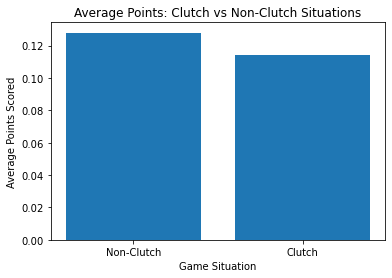

In [19]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import when, col, avg
import matplotlib.pyplot as plt

spark = SparkSession.builder.getOrCreate()

df_final = spark.read.parquet("processed_data/clutch_events.parquet")

df_clutch = df_final.withColumn(
    "clutch",
    when(col("seconds_left") <= 120, 1).otherwise(0)
)
clutch_stats = (
    df_clutch.groupBy("clutch")
    .agg(avg("points").alias("avg_points"))
    .orderBy("clutch")
)


rows = clutch_stats.collect()

labels = []
values = []
for row in rows:
    if row["clutch"] == 0:
        labels.append("Non-Clutch")
    else:
        labels.append("Clutch")
    values.append(row["avg_points"])

# Plot
plt.figure()
plt.bar(labels, values)
plt.title("Average Points: Clutch vs Non-Clutch Situations")
plt.xlabel("Game Situation")
plt.ylabel("Average Points Scored")
plt.show()


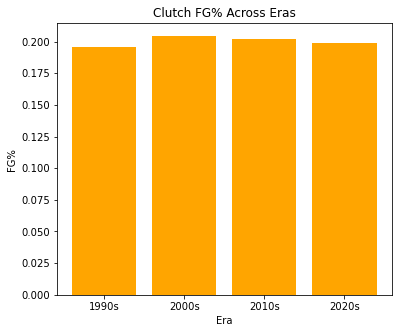

In [20]:
df = df_era_final.collect()

eras = [row["era"] for row in df]
fg_pct = [row["fg_pct"] for row in df]

plt.figure(figsize=(6,5))
plt.bar(eras, fg_pct, color='orange')
plt.title("Clutch FG% Across Eras")
plt.ylabel("FG%")
plt.xlabel("Era")
plt.show()
